In [7]:
import matplotlib.pyplot as plt
import pandas as pd

from june_events import (
    inspect_file,
    load_enriched_events,
)

# Edit this
Put here the path to the events file

In [8]:
EVENTS_PATH = "../path/to/simulation_events.h5"

# Inspect File
To give an idea of the structure of the .h5 file

In [2]:
summary = inspect_file(EVENTS_PATH)
for dataset in summary.datasets:
    print(dataset.path, dataset.n_rows, dataset.dtype)
print("registries:", list(summary.registries))

events/coordinated_encounters 468819614 {'names': ['person_a', 'person_b', 'time', 'encounter_type_id', 'slot', 'group_id'], 'formats': ['<i4', '<i4', '<f8', 'u1', '<i4', '<u8'], 'offsets': [0, 4, 8, 16, 20, 24], 'itemsize': 32}
events/deaths 3135581 [('person_id', '<i4'), ('venue_id', '<i4'), ('time', '<f8')]
events/infections 4415655 {'names': ['person_id', 'infector_id', 'venue_id', 'time', 'encounter_type_id', 'transmission_mode_index', 'infector_symptom_id', 'source'], 'formats': ['<i4', '<i4', '<i4', '<f8', 'u1', 'u1', '<u2', 'u1'], 'offsets': [0, 4, 8, 16, 24, 25, 26, 28], 'itemsize': 32}
events/symptom_changes 14666645 {'names': ['person_id', 'venue_id', 'time', 'old_symptom_id', 'new_symptom_id'], 'formats': ['<i4', '<i4', '<f8', '<u2', '<u2'], 'offsets': [0, 4, 8, 16, 18], 'itemsize': 24}
lookups/people 4412155 {'names': ['person_id', 'age', 'sex', 'geo_unit_id', 'is_dead', 'death_time', 'schedule_type', 'num_activities', 'num_residence_venues', 'num_primary_activities', 'num

# Example 1: new infections by day

In [3]:
infections = load_enriched_events(EVENTS_PATH, "events/infections")
infections_per_day = infections.groupby(infections["time"].astype(int)).size()
infections_per_day

time
1      100
6        1
7        1
8        2
9        4
      ... 
939     25
940     25
941     25
942     27
943     14
Length: 881, dtype: int64

Text(0.5, 1.0, 'Infections per day')

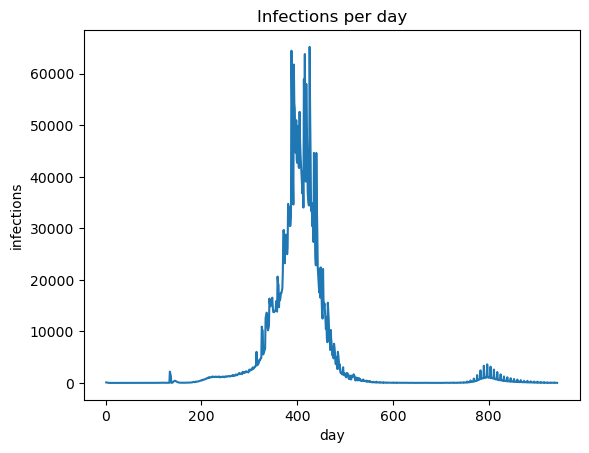

In [4]:
fig, ax = plt.subplots()
infections_per_day.plot(ax=ax)
ax.set_xlabel("day")
ax.set_ylabel("infections")
ax.set_title("Infections per day")

# Example 2: infection events by venue_type

Text(0.5, 1.0, 'Infections by venue type')

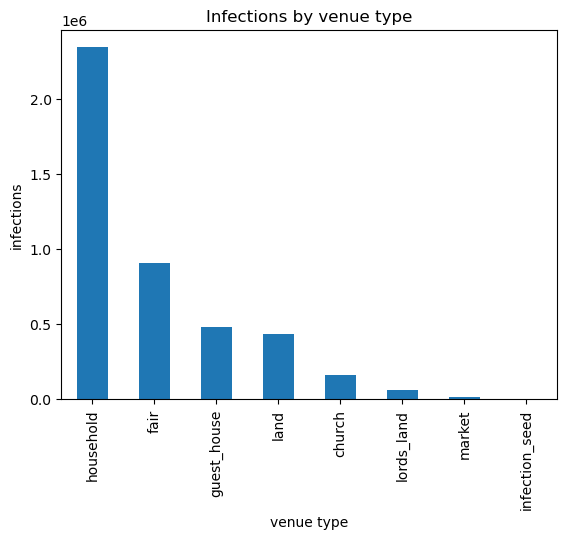

In [5]:
infections_by_venue_type = infections["venue_type"].value_counts()

fig, ax = plt.subplots()
infections_by_venue_type.plot(kind="bar", ax=ax)
ax.set_xlabel("venue type")
ax.set_ylabel("infections")
ax.set_title("Infections by venue type")

# Example 3: deaths by week, split by sex

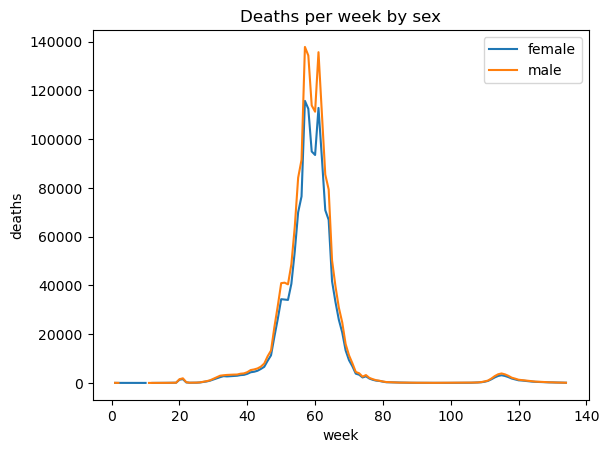

In [6]:
deaths = load_enriched_events(EVENTS_PATH, "events/deaths")
deaths_per_week = deaths.groupby([(deaths["time"] // 7).astype(int), "person_sex"]).size()
deaths_per_week = deaths_per_week.unstack("person_sex")

fig, ax = plt.subplots()
for sex in deaths_per_week.columns:
    ax.plot(deaths_per_week.index, deaths_per_week[sex], label=sex)
ax.set_xlabel("week")
ax.set_ylabel("deaths")
ax.set_title("Deaths per week by sex")
ax.legend()